# Prior Predictive Checks

**Project:** *Why Do Significant Railway Accident Rates Differ Across Europe? A Fully Bayesian Hierarchical Analysis of Railway Safety*

This notebook simulates complete accident datasets from the priors for the three candidate models before any posterior fitting.

Models:

- **M1:** Poisson regression
- **M2:** Negative binomial regression
- **M3:** Hierarchical negative binomial regression

The real dataset is used only for its actual 405-row design, years, train-km exposures, country structure, and observed reference statistics.


## 1. Imports, settings, and paths

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_SEED = 2026
N_SIMULATIONS = 2000
rng = np.random.default_rng(RANDOM_SEED)

DATA_PATH = "../data/processed/railway_country_year_2010_2024.csv"
FIGURE_DIR = Path("../figures/prior_predictive")
TABLE_DIR = Path("../tables/prior_predictive")
RESULT_DIR = Path("../results/prior_predictive")

for folder in [FIGURE_DIR, TABLE_DIR, RESULT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Prior simulations per model:", N_SIMULATIONS)


Prior simulations per model: 2000


## 2. Load and validate the frozen dataset

In [2]:
data = pd.read_csv(DATA_PATH)
data["accidents"] = data["accidents"].astype(int)

assert len(data) == 405
assert data["country"].nunique() == 27
assert data["year"].nunique() == 15
assert data["year"].min() == 2010
assert data["year"].max() == 2024
assert data.isna().sum().sum() == 0
assert data.duplicated(["country", "year"]).sum() == 0
assert (data["train_km"] > 0).all()

print("Dataset validation passed.")
print(data.head())


Dataset validation passed.
   year country  accidents  train_km country_name  year_centered  \
0  2010      AT         79     156.1      Austria             -7   
1  2011      AT         84     152.2      Austria             -6   
2  2012      AT         87     149.8      Austria             -5   
3  2013      AT         73     150.7      Austria             -4   
4  2014      AT         61     152.4      Austria             -3   

   accidents_per_million_train_km  country_id  
0                        0.506086           1  
1                        0.551905           1  
2                        0.580774           1  
3                        0.484406           1  
4                        0.400262           1  


## 3. Prepare the real design structure

In [3]:
y_observed = data["accidents"].to_numpy()
year_centered = data["year_centered"].to_numpy()
train_km = data["train_km"].to_numpy()

country_index = data["country_id"].astype(int).to_numpy() - 1
N_COUNTRIES = data["country_id"].nunique()

years = np.sort(data["year"].unique())
year_index = np.searchsorted(years, data["year"])
N_YEARS = len(years)

country_exposure = np.bincount(
    country_index,
    weights=train_km,
    minlength=N_COUNTRIES,
)

year_exposure = np.bincount(
    year_index,
    weights=train_km,
    minlength=N_YEARS,
)

print("Countries:", N_COUNTRIES)
print("Years:", N_YEARS)


Countries: 27
Years: 15


## 4. Summary statistics used for prior predictive checking

For each observed or simulated dataset we compare:

- total accidents;
- mean count;
- count variance;
- number of zero observations;
- maximum country-year count;
- between-country variance in exposure-adjusted rates;
- 2010 and 2024 aggregate rates;
- 2024-to-2010 rate ratio.


In [4]:
def calculate_statistics(y):
    y = np.asarray(y)

    country_totals = np.bincount(
        country_index,
        weights=y,
        minlength=N_COUNTRIES,
    )
    country_rates = country_totals / country_exposure

    yearly_totals = np.bincount(
        year_index,
        weights=y,
        minlength=N_YEARS,
    )
    yearly_rates = yearly_totals / year_exposure

    return {
        "total_accidents": y.sum(),
        "mean_count": y.mean(),
        "variance_count": y.var(ddof=1),
        "zero_count": (y == 0).sum(),
        "maximum_count": y.max(),
        "variance_country_rates": country_rates.var(ddof=1),
        "rate_2010": yearly_rates[0],
        "rate_2024": yearly_rates[-1],
        "rate_ratio_2024_2010": (
            yearly_rates[-1] / yearly_rates[0]
            if yearly_rates[0] > 0 else np.nan
        ),
    }

observed_statistics = calculate_statistics(y_observed)
observed_statistics_df = pd.DataFrame([observed_statistics])

print(observed_statistics_df.T.rename(columns={0: "Observed value"}))

observed_statistics_df.to_csv(
    TABLE_DIR / "observed_statistics.csv",
    index=False,
)


                        Observed value
total_accidents           27121.000000
mean_count                   66.965432
variance_count             6579.340386
zero_count                    7.000000
maximum_count               488.000000
variance_country_rates        0.383873
rate_2010                     0.617052
rate_2024                     0.374355
rate_ratio_2024_2010          0.606684


## 5. Priors

The provisional priors are:

$$
\alpha \sim N(\log(0.5), 1^2)
$$

$$
\beta \sim N(0, 0.05^2)
$$

For M2 and M3:

$$
\log(r) \sim N(\log(10),1^2),\qquad r=\exp(\log r)
$$

For M3:

$$
\sigma_{country}\sim \text{Half-Normal}(0,1)
$$

and

$$
u_i=\sigma_{country}z_i,\qquad z_i\sim N(0,1).
$$



## 6. Prior predictive simulator

In [5]:
def simulate_prior_dataset(model_name):
    # Shared priors
    alpha = rng.normal(loc=np.log(0.5), scale=0.5)
    beta = rng.normal(loc=0.0, scale=0.05)

    if model_name == "M1_Poisson":
        log_mu = np.log(train_km) + alpha + beta * year_centered
        mu = np.exp(log_mu)
        y = rng.poisson(mu)
        r = np.nan
        sigma_country = np.nan

    elif model_name == "M2_Negative_Binomial":
        log_r = rng.normal(loc=np.log(10), scale=1.0)
        r = np.exp(log_r)

        log_mu = np.log(train_km) + alpha + beta * year_centered
        mu = np.exp(log_mu)
        p = r / (r + mu)
        y = rng.negative_binomial(n=r, p=p)
        sigma_country = np.nan

    elif model_name == "M3_Hierarchical_Negative_Binomial":
        log_r = rng.normal(loc=np.log(10), scale=1.0)
        r = np.exp(log_r)

        sigma_country = abs(rng.normal(loc=0.0, scale=0.5))
        z = rng.normal(loc=0.0, scale=1.0, size=N_COUNTRIES)
        country_effects = sigma_country * z

        log_mu = (
            np.log(train_km)
            + alpha
            + beta * year_centered
            + country_effects[country_index]
        )
        mu = np.exp(log_mu)
        p = r / (r + mu)
        y = rng.negative_binomial(n=r, p=p)

    else:
        raise ValueError(f"Unknown model: {model_name}")

    statistics = calculate_statistics(y)
    statistics.update({
        "alpha": alpha,
        "baseline_rate": np.exp(alpha),
        "beta": beta,
        "annual_rate_ratio": np.exp(beta),
        "annual_percent_change": 100 * (np.exp(beta) - 1),
        "r": r,
        "sigma_country": sigma_country,
    })

    return y, statistics


## 7. Simulate 2,000 complete datasets from each model

In [6]:
MODEL_NAMES = [
    "M1_Poisson",
    "M2_Negative_Binomial",
    "M3_Hierarchical_Negative_Binomial",
]

prior_results = []
yearly_rate_results = []

for model_name in MODEL_NAMES:
    print(f"Simulating {model_name}...")

    for simulation in range(N_SIMULATIONS):
        y_simulated, statistics = simulate_prior_dataset(model_name)

        statistics["model"] = model_name
        statistics["simulation"] = simulation + 1
        prior_results.append(statistics)

        yearly_totals = np.bincount(
            year_index,
            weights=y_simulated,
            minlength=N_YEARS,
        )
        yearly_rates = yearly_totals / year_exposure

        for year, rate in zip(years, yearly_rates):
            yearly_rate_results.append({
                "model": model_name,
                "simulation": simulation + 1,
                "year": year,
                "rate": rate,
            })

prior_results = pd.DataFrame(prior_results)
yearly_rate_results = pd.DataFrame(yearly_rate_results)

prior_results.to_csv(
    RESULT_DIR / "prior_predictive_statistics.csv",
    index=False,
)

yearly_rate_results.to_csv(
    RESULT_DIR / "prior_predictive_yearly_rates.csv",
    index=False,
)

print("Prior predictive simulation completed.")
print("Dataset-level simulation rows:", len(prior_results))


Simulating M1_Poisson...
Simulating M2_Negative_Binomial...
Simulating M3_Hierarchical_Negative_Binomial...
Prior predictive simulation completed.
Dataset-level simulation rows: 6000


## 8. Numerical prior predictive summary

In [7]:
STATISTICS_TO_CHECK = [
    "total_accidents",
    "mean_count",
    "variance_count",
    "zero_count",
    "maximum_count",
    "variance_country_rates",
    "rate_ratio_2024_2010",
]

summary_rows = []

for model_name in MODEL_NAMES:
    model_data = prior_results[prior_results["model"] == model_name]

    for statistic in STATISTICS_TO_CHECK:
        values = model_data[statistic].dropna()

        summary_rows.append({
            "model": model_name,
            "statistic": statistic,
            "observed": observed_statistics[statistic],
            "prior_mean": values.mean(),
            "prior_median": values.median(),
            "prior_2.5%": values.quantile(0.025),
            "prior_97.5%": values.quantile(0.975),
        })

prior_summary = pd.DataFrame(summary_rows)
prior_summary["observed_inside_95%_prior_interval"] = (
    (prior_summary["observed"] >= prior_summary["prior_2.5%"]) &
    (prior_summary["observed"] <= prior_summary["prior_97.5%"])
)

print(prior_summary.to_string(index=False))

prior_summary.to_csv(
    TABLE_DIR / "prior_predictive_summary.csv",
    index=False,
)


                            model              statistic     observed   prior_mean  prior_median   prior_2.5%   prior_97.5%  observed_inside_95%_prior_interval
                       M1_Poisson        total_accidents 27121.000000 33010.235500  29073.500000 11290.675000  76411.600000                                True
                       M1_Poisson             mean_count    66.965432    81.506754     71.786420    27.878210    188.670617                                True
                       M1_Poisson         variance_count  6579.340386 20475.147342  12202.780516  1810.014095  86701.428225                                True
                       M1_Poisson             zero_count     7.000000     2.476500      1.000000     0.000000     14.000000                                True
                       M1_Poisson          maximum_count   488.000000   824.465500    695.000000   263.000000   2048.025000                                True
                       M1_Poisson varian

## 9. Inspect the parameter priors

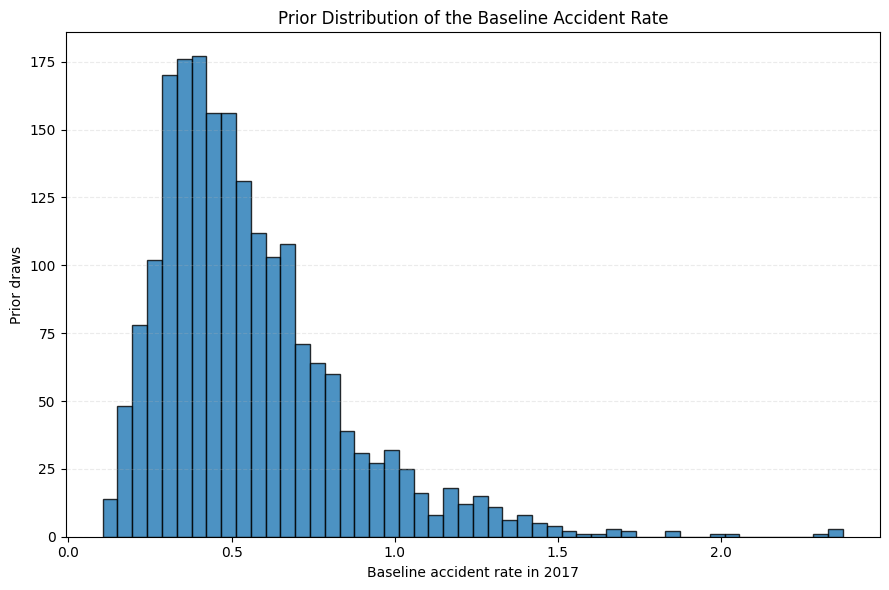

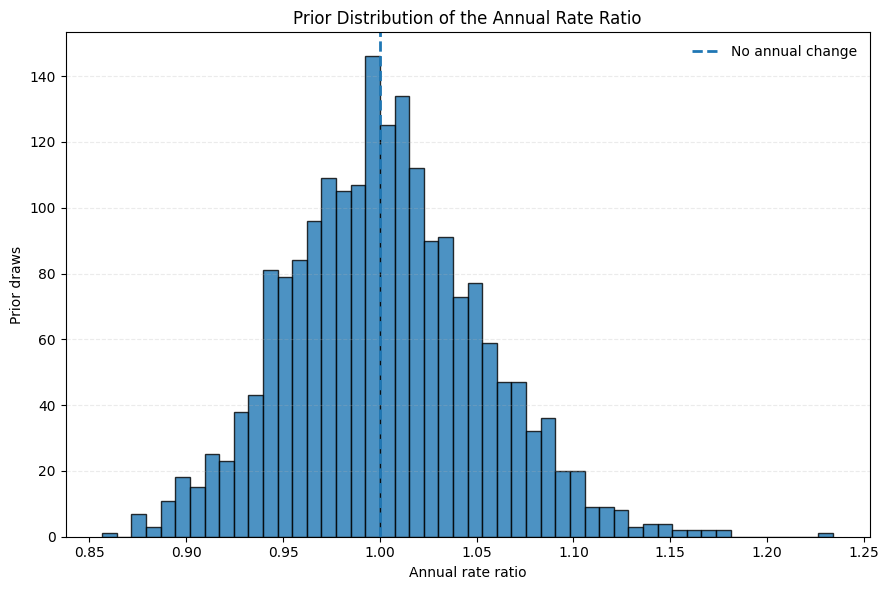

In [8]:
# Figure 1 — Prior baseline accident rate
fig, ax = plt.subplots(figsize=(9, 6))

ax.hist(
    prior_results.loc[
        prior_results["model"] == "M1_Poisson",
        "baseline_rate",
    ],
    bins=50,
    edgecolor="black",
    alpha=0.8,
)

ax.set(
    xlabel="Baseline accident rate in 2017",
    ylabel="Prior draws",
    title="Prior Distribution of the Baseline Accident Rate",
)
ax.grid(axis="y", alpha=0.25, linestyle="--")
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "01_prior_baseline_rate.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# Figure 2 — Prior annual rate ratio
fig, ax = plt.subplots(figsize=(9, 6))

ax.hist(
    prior_results.loc[
        prior_results["model"] == "M1_Poisson",
        "annual_rate_ratio",
    ],
    bins=50,
    edgecolor="black",
    alpha=0.8,
)

ax.axvline(
    1,
    linestyle="--",
    linewidth=2,
    label="No annual change",
)

ax.set(
    xlabel="Annual rate ratio",
    ylabel="Prior draws",
    title="Prior Distribution of the Annual Rate Ratio",
)
ax.grid(axis="y", alpha=0.25, linestyle="--")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "02_prior_annual_rate_ratio.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 10. Prior predictive comparison plots

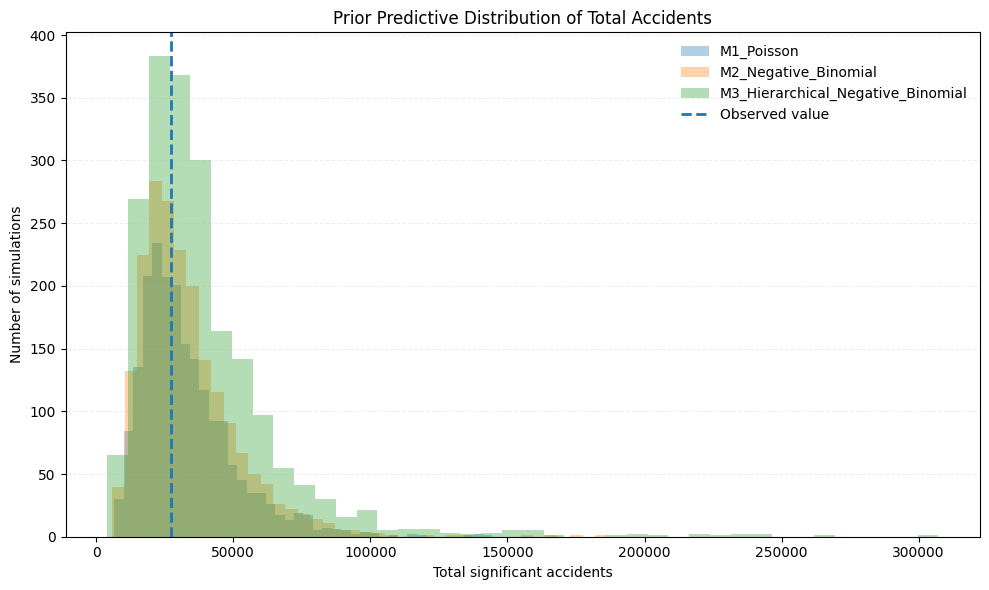

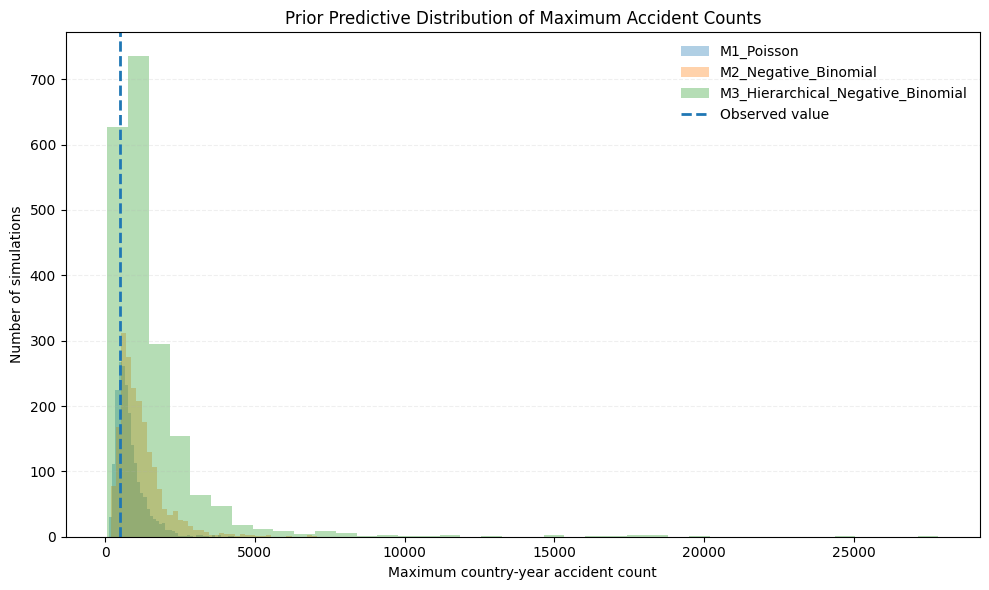

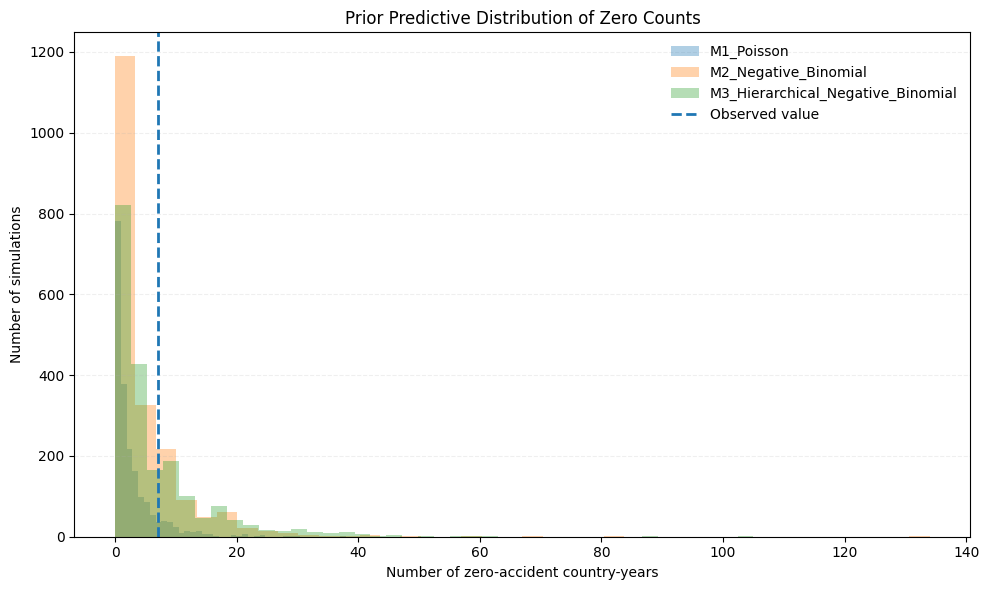

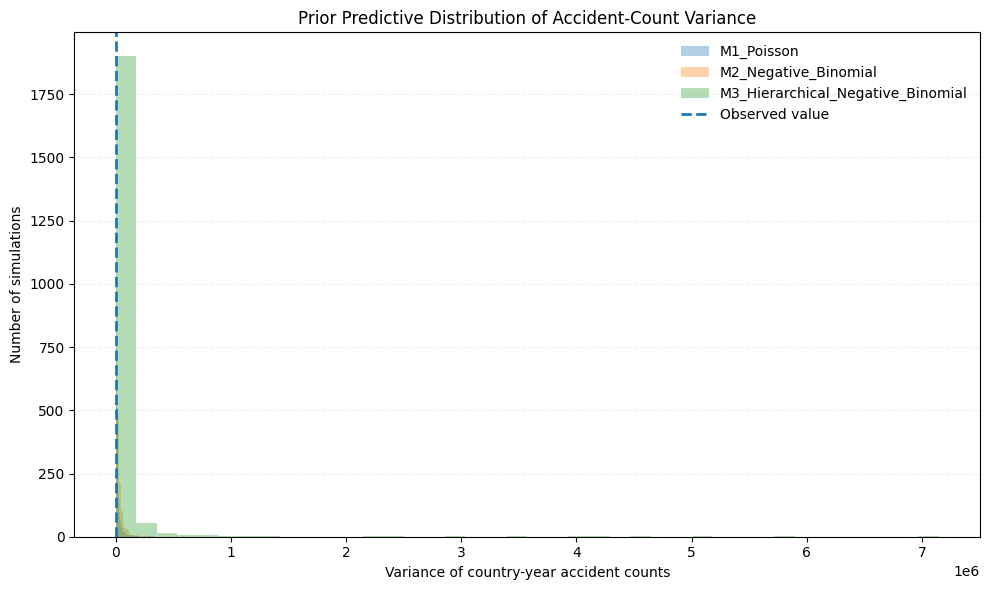

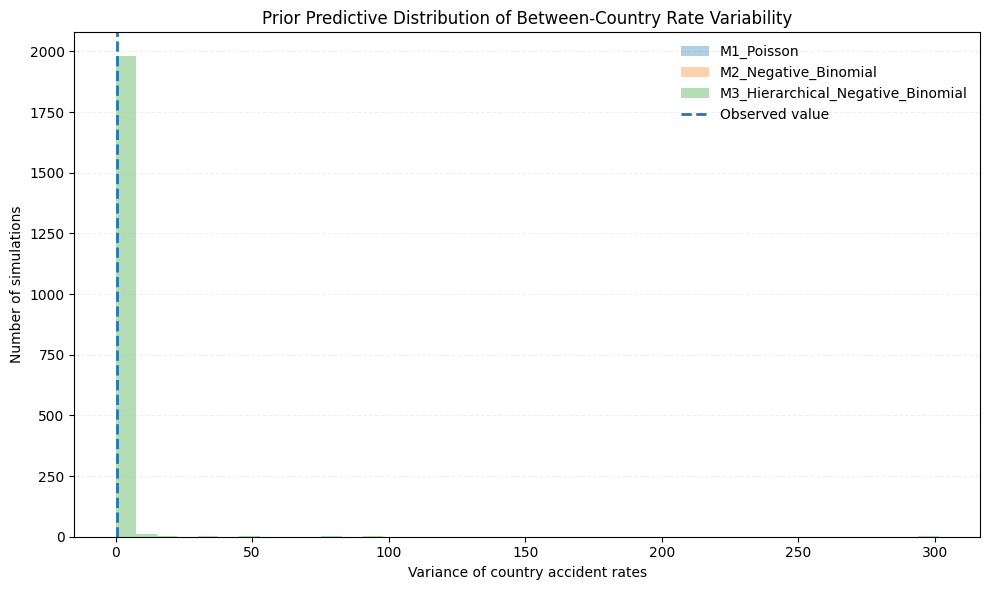

In [9]:
def plot_prior_predictive(statistic, xlabel, title, filename):
    fig, ax = plt.subplots(figsize=(10, 6))

    for model_name in MODEL_NAMES:
        values = prior_results.loc[
            prior_results["model"] == model_name,
            statistic,
        ].dropna()

        ax.hist(
            values,
            bins=40,
            alpha=0.35,
            label=model_name,
        )

    ax.axvline(
        observed_statistics[statistic],
        linestyle="--",
        linewidth=2,
        label="Observed value",
    )

    ax.set(
        xlabel=xlabel,
        ylabel="Number of simulations",
        title=title,
    )
    ax.grid(axis="y", alpha=0.2, linestyle="--")
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


plot_prior_predictive(
    "total_accidents",
    "Total significant accidents",
    "Prior Predictive Distribution of Total Accidents",
    "03_prior_predictive_total_accidents.png",
)

plot_prior_predictive(
    "maximum_count",
    "Maximum country-year accident count",
    "Prior Predictive Distribution of Maximum Accident Counts",
    "04_prior_predictive_maximum_count.png",
)

plot_prior_predictive(
    "zero_count",
    "Number of zero-accident country-years",
    "Prior Predictive Distribution of Zero Counts",
    "05_prior_predictive_zero_counts.png",
)

plot_prior_predictive(
    "variance_count",
    "Variance of country-year accident counts",
    "Prior Predictive Distribution of Accident-Count Variance",
    "06_prior_predictive_variance.png",
)

plot_prior_predictive(
    "variance_country_rates",
    "Variance of country accident rates",
    "Prior Predictive Distribution of Between-Country Rate Variability",
    "07_prior_predictive_country_variability.png",
)


## 11. Prior predictive yearly-rate patterns

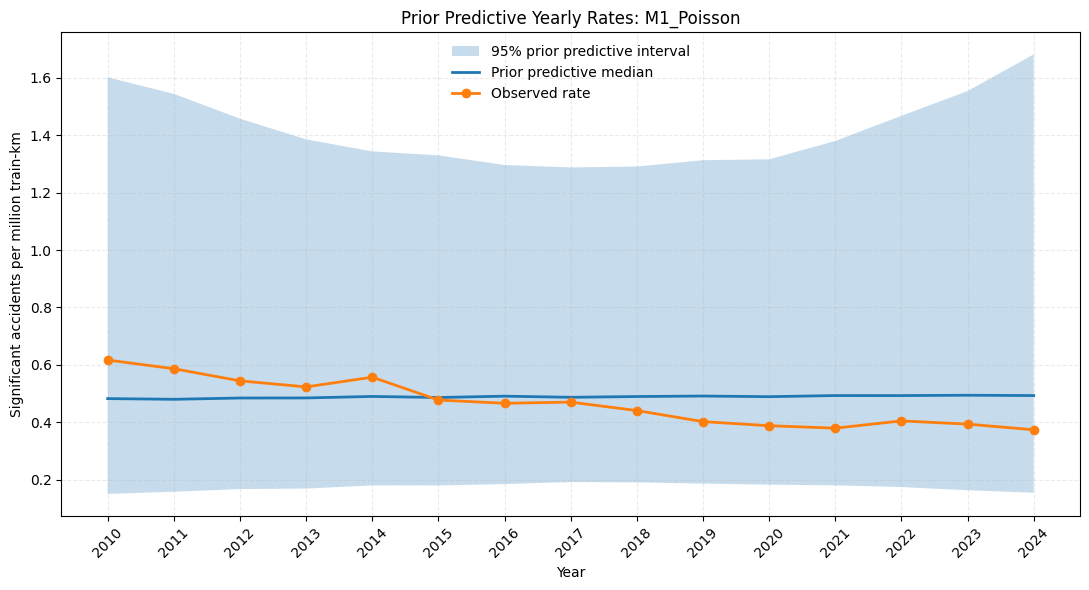

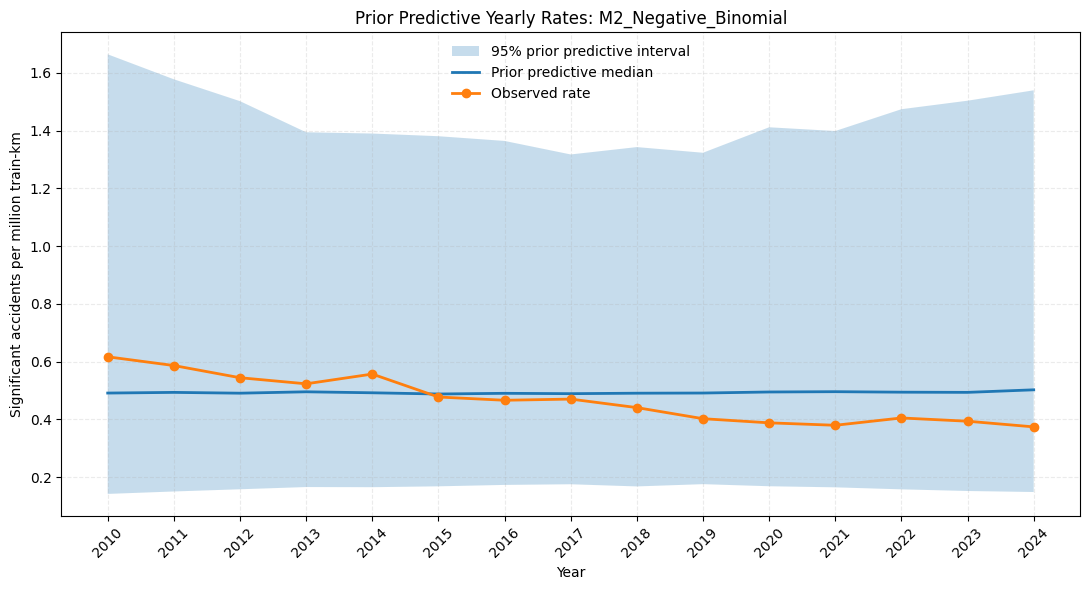

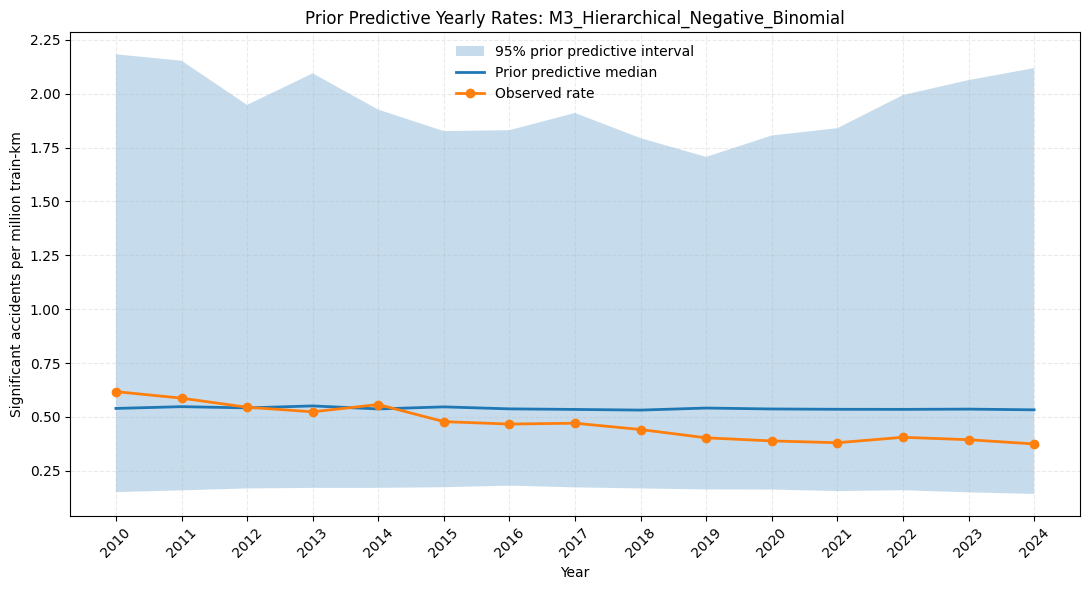

In [10]:
observed_yearly = (
    data.groupby("year", as_index=False)
    .agg(
        total_accidents=("accidents", "sum"),
        total_train_km=("train_km", "sum"),
    )
)

observed_yearly["observed_rate"] = (
    observed_yearly["total_accidents"]
    / observed_yearly["total_train_km"]
)

yearly_prior_summary = (
    yearly_rate_results
    .groupby(["model", "year"])["rate"]
    .agg(
        prior_median="median",
        prior_lower=lambda x: x.quantile(0.025),
        prior_upper=lambda x: x.quantile(0.975),
    )
    .reset_index()
)

yearly_prior_summary.to_csv(
    TABLE_DIR / "prior_predictive_yearly_rate_summary.csv",
    index=False,
)

for model_name in MODEL_NAMES:
    model_yearly = yearly_prior_summary[
        yearly_prior_summary["model"] == model_name
    ]

    fig, ax = plt.subplots(figsize=(11, 6))

    ax.fill_between(
        model_yearly["year"],
        model_yearly["prior_lower"],
        model_yearly["prior_upper"],
        alpha=0.25,
        label="95% prior predictive interval",
    )

    ax.plot(
        model_yearly["year"],
        model_yearly["prior_median"],
        linewidth=2,
        label="Prior predictive median",
    )

    ax.plot(
        observed_yearly["year"],
        observed_yearly["observed_rate"],
        marker="o",
        linewidth=2,
        label="Observed rate",
    )

    ax.set(
        xlabel="Year",
        ylabel="Significant accidents per million train-km",
        title=f"Prior Predictive Yearly Rates: {model_name}",
    )
    ax.set_xticks(years)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.25, linestyle="--")
    ax.legend(frameon=False)
    fig.tight_layout()

    fig.savefig(
        FIGURE_DIR / f"08_yearly_rates_{model_name}.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
